# **Implementación del caso de 10 Qubits.**

In [37]:
%load_ext autoreload
%autoreload 2

from modules import schnorr_lattice as sl
from modules import qaoa as q
from modules import utils

import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
N10 = 261980999226229

## **1. Implementación con 9 Qubits**

In [40]:
seed = 51

In [42]:
nineQubit = sl.schnorrCVP(N10, 4, 1, seed)

El numero de bits de N = 261980999226229 es m = 48
La dimension del reticulo que vamos a tratar es n = 9
La cota smooth que vamos a tomar: 162


### **1.1 Algoritmo de Schnorr**

In [5]:
cvpinstance = nineQubit.generate_cvp(10)

B = 
[ 3 0 0 0 0 0 0 0 0  6931 ]
[ 0 2 0 0 0 0 0 0 0 10986 ]
[ 0 0 1 0 0 0 0 0 0 16094 ]
[ 0 0 0 4 0 0 0 0 0 19459 ]
[ 0 0 0 0 1 0 0 0 0 23979 ]
[ 0 0 0 0 0 5 0 0 0 25649 ]
[ 0 0 0 0 0 0 3 0 0 28332 ]
[ 0 0 0 0 0 0 0 2 0 29444 ]
[ 0 0 0 0 0 0 0 0 4 31355 ]
t = 
(0, 0, 0, 0, 0, 0, 0, 0, 0, 331993)


In [6]:
cvpResult = nineQubit.babai_algorithm(cvpinstance, delta = 0.99)
print(f'D = \n{cvpResult.D}\n')
print(f'b_op = \n{cvpResult.b_op}\n')
print(f'res_vector = \n{cvpResult.res_vector}\n')
print(f'step_sign = \n{cvpResult.step_sign}\n')
print(f'weights = \n{cvpResult.weight}\n')

D = 
[  3 -2  1  0  2 0  3 -6  0 -3 ]
[  0 -2  2  0 -2 5 -3  2  0  5 ]
[  6  0  2  0 -2 0  0 -2  4  3 ]
[ -3  2 -6  4  3 0 -3  2  0 -1 ]
[  3  0  2  4  0 0 -6  2 -4  3 ]
[ -3  4  2 -4 -1 5  0 -2  0 -4 ]
[ -6 -4 -1  4  0 0 -3  2  4 -2 ]
[ -3  0  2  4 -3 0  6 -2  0 -1 ]
[ -3  2  2  0  2 0 -6 -4  4  4 ]

b_op = 
[    -3      2      4      0      6      0      0      6      4 331992]

res_vector = 
[ 3 -2 -4  0 -6  0  0 -6 -4  1]

step_sign = 
[ 1  1  1  1  1 -1 -1  1 -1]

weights = 
(-8004, 29891, -11366, 4499, -17680, -29891, -27828, 11118, 21515)



### **1.2 Algoritmo QAOA**

In [7]:
qubo9 = q.define_qubo(cvpResult.D, cvpResult.res_vector, cvpResult.step_sign, nineQubit.n)
print(qubo9.prettyprint())

Hc9, offset9 = q.define_hamiltonian(qubo9)
print(f'Offset = {offset9}')
print(f'Hamiltonian = {Hc9}')

Problem name: quboProblem

Minimize
  72*z_0^2 - 68*z_0*z_1 + 38*z_0*z_2 - 62*z_0*z_3 - 56*z_0*z_4 - 14*z_0*z_5
  + 52*z_0*z_6 + 40*z_0*z_7 + 26*z_0*z_8 + 75*z_1^2 + 38*z_1*z_2 - 28*z_1*z_3
  + 82*z_1*z_4 + 2*z_1*z_5 - 18*z_1*z_6 - 34*z_1*z_7 - 52*z_1*z_8 + 73*z_2^2
  - 86*z_2*z_3 + 22*z_2*z_4 + 40*z_2*z_5 + 64*z_2*z_6 - 14*z_2*z_7 - 36*z_2*z_8
  + 88*z_3^2 + 28*z_3*z_4 + 28*z_3*z_5 - 94*z_3*z_6 - 34*z_3*z_7 - 26*z_3*z_8
  + 94*z_4^2 + 74*z_4*z_5 + 8*z_4*z_6 - 64*z_4*z_7 - 38*z_4*z_8 + 91*z_5^2
  - 24*z_5*z_6 - 16*z_5*z_7 + 22*z_5*z_8 + 102*z_6^2 - 24*z_6*z_7 + 52*z_6*z_8
  + 79*z_7^2 + 50*z_7*z_8 + 105*z_8^2 - 60*z_0 - 2*z_1 - 42*z_2 + 40*z_3
  - 16*z_4 - 22*z_5 - 72*z_6 - 24*z_7 - 42*z_8 + 118

Subject to
  No constraints

  Binary variables (9)
    z_0 z_1 z_2 z_3 z_4 z_5 z_6 z_7 z_8

Offset = 357.0
Hamiltonian = SparsePauliOp(['IIIIIIIIZ', 'IIIIIIZII', 'IIIIIZIII', 'IIIIZIIII', 'IIIZIIIII', 'IIZIIIIII', 'IZIIIIIII', 'ZIIIIIIII', 'IIIIIIIZI', 'IIIIIIIZZ', 'IIIIIIZIZ', 'IIIIIZIIZ', '

In [8]:
circuit9 = q.construct_circuit(Hc9, reps = 1)
print(circuit9)

     ┌───┐  ┌─────────────┐                                                  »
q_0: ┤ H ├──┤ Rz(10*γ[0]) ├───■────────────────■─────────────■───────────────»
     ├───┤ ┌┴─────────────┴─┐ │ZZ((-34)*γ[0])  │             │               »
q_1: ┤ H ├─┤ Rz((-34)*γ[0]) ├─■────────────────┼─────────────┼───────────────»
     ├───┤ ├────────────────┤                  │ZZ(19*γ[0])  │               »
q_2: ┤ H ├─┤ Rz((-64)*γ[0]) ├──────────────────■─────────────┼───────────────»
     ├───┤ └─┬────────────┬─┘                                │ZZ((-31)*γ[0]) »
q_3: ┤ H ├───┤ Rz(9*γ[0]) ├──────────────────────────────────■───────────────»
     ├───┤┌──┴────────────┴─┐                                                »
q_4: ┤ H ├┤ Rz((-106)*γ[0]) ├────────────────────────────────────────────────»
     ├───┤├─────────────────┤                                                »
q_5: ┤ H ├┤ Rz((-125)*γ[0]) ├────────────────────────────────────────────────»
     ├───┤└┬────────────────┤                       

In [9]:
x0 = np.asarray([0.0]*circuit9.num_parameters)
_, optParameters9 = q.qaoa_algorithm(circuit9, Hc9, x0)

In [10]:
for param in optParameters9.items():
    print(f'{param[0]} = {param[1]}')

β[0] = -0.45476078832144157
γ[0] = 0.010736647791453217


In [11]:
results9 = q.sample_from_parameters(circuit9, list(optParameters9.values()), shots = 10_000)
print(len(results9))
for bitstring, count in results9.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

423
Bistring: 000000000 -> Counts: 281
Bistring: 000000001 -> Counts: 274
Bistring: 011001011 -> Counts: 203
Bistring: 000000011 -> Counts: 178
Bistring: 001001011 -> Counts: 164
Bistring: 000010001 -> Counts: 151
Bistring: 100001111 -> Counts: 147
Bistring: 011001100 -> Counts: 146
Bistring: 011001000 -> Counts: 146
Bistring: 100001011 -> Counts: 143
Bistring: 010010001 -> Counts: 137
Bistring: 010000000 -> Counts: 136
Bistring: 001000000 -> Counts: 132
Bistring: 000001011 -> Counts: 129
Bistring: 011000000 -> Counts: 129
Bistring: 000000100 -> Counts: 126
Bistring: 001001001 -> Counts: 120
Bistring: 100000011 -> Counts: 120
Bistring: 011011001 -> Counts: 116
Bistring: 000001101 -> Counts: 112
Bistring: 010001100 -> Counts: 111
Bistring: 011001010 -> Counts: 110
Bistring: 011001001 -> Counts: 109
Bistring: 100000000 -> Counts: 109
Bistring: 010010000 -> Counts: 109
Bistring: 000001100 -> Counts: 106
Bistring: 001001000 -> Counts: 104
Bistring: 100001100 -> Counts: 100
Bistring: 010001

### **1.3 Obtención de SR-Pairs**

In [12]:
nD9 = sl.integer_to_matrix(cvpResult.D)
vnew9 = sl.bitstring2latticeVectors(nD9, results9.keys(), cvpResult.step_sign, cvpResult.b_op)
for vect9 in vnew9:
    print(vect9)

[    -3      2      4      0      6      0      0      6      4 331992]
[     0      0      5      0      8      0      3      0      4 331989]
[     0      4      4      4      6      5      6      0      0 331994]
[     0     -2      7      0      6      5      0      2      4 331994]
[     3      4      2      0      9      5      0      2      0 331995]
[     3      0      7      4      8      0     -3      2      0 331992]
[     6     -2      1      4      5      5      3      6      4 331992]
[     3      8      3      4      4      0      6      2      4 331995]
[    -3      8      1      4      6      0      6      4      0 331992]
[     0     -2     -1      4      7      5      3      8      0 331989]
[     0      0      9      8      5      0      3      0      0 331991]
[    -6      2      6      4      3      0      6      4      4 331991]
[     3      6      5     -4      6      0      3      4      0 331994]
[    -3      0      1      4      9      5     -3      4      4 

In [13]:
distances9 = utils.get_distances(vnew9, cvpinstance.t)
for dist in distances9:
    print(dist)

10.862780491200215
11.40175425099138
12.083045973594572
11.61895003862225
11.958260743101398
12.328828005937952
13.0
13.19090595827292
13.379088160259652
13.564659966250536
13.527749258468683
13.152946437965905
12.165525060596439
13.152946437965905
13.379088160259652
12.206555615733702
13.564659966250536
13.114877048604
14.66287829861518
13.379088160259652
14.071247279470288
13.114877048604
14.866068747318506
13.45362404707371
13.674794331177344
13.820274961085254
13.490737563232042
13.856406460551018
14.142135623730951
13.784048752090222
13.601470508735444
13.820274961085254
14.352700094407323
13.2664991614216
14.38749456993816
14.0
13.820274961085254
14.247806848775006
14.422205101855956
14.177446878757825
14.212670403551895
14.352700094407323
15.231546211727817
14.560219778561036
14.0
15.0
13.92838827718412
13.674794331177344
15.033296378372908
14.933184523068078
15.033296378372908
13.856406460551018
15.7797338380595
16.186414056238647
14.866068747318506
15.684387141358123
15.588457

In [14]:
nB9 = sl.integer_to_matrix(cvpinstance.B)
uv_pairs9 = sl.vectors2uv_pairs(nB9, vnew9, nineQubit.n)
print(uv_pairs9)

[[524017778769375 2]
 [261919757721875 1]
 [262070340406875 1]
 [786268596953125 3]
 [262085885854650 1]
 [4454645495781250 17]
 [786090185460580 3]
 [262103661492750 1]
 [523979406758115 2]
 [3928742035595377 15]
 [262022427734375 1]
 [1047973394015625 4]
 [1834661788368750 7]
 [8908008053659715 34]
 [262078995234375 1]
 [262122855843750 1]
 [261916113620898 1]
 [2358048622393750 9]
 [6026431990713750 23]
 [261944408993190 1]
 [524036013402825 2]
 [524319046626375 2]
 [4976110986617925 19]
 [261924785441275 1]
 [524223188671875 2]
 [4454570333762703 17]
 [1310026220218089 5]
 [6548735929644678 25]
 [1047938786019125 4]
 [262107308203125 1]
 [30655088443768250 117]
 [262119208917060 1]
 [1309301628738796 5]
 [262038715317500 1]
 [262098652440625 1]
 [1572443919921875 6]
 [262159937104450 1]
 [18074816137262500 69]
 [3408191733581250 13]
 [6030537433593750 23]
 [786283689888125 3]
 [6026040415499676 23]
 [786043559050750 3]
 [1048652683203125 4]
 [2618305201197147 10]
 [9952360440859375

In [15]:
sr_pairs9 = sl.uv_pairs2sr_pairs(uv_pairs9, nineQubit)
print(sr_pairs9)

[]


In [16]:
probs9 = utils.get_probs(results9.values(), shots = 10_000)

In [17]:
utils.prettyprint(vnew9, distances9, probs9, cvpResult.b_op, cvpResult.res_vector)

Vector más corto por algoritmo de Babai: 
b_op = [    -3      2      4      0      6      0      0      6      4 331992]

El vector residual 
t - b_op = [ 3 -2 -4  0 -6  0  0 -6 -4  1]

La distancia |t - b_op| = 10.863

0: Prob = 0.02810
	vnew = [    -3      2      4      0      6      0      0      6      4 331992] con distancia: 10.863
1: Prob = 0.02740
	vnew = [     0      0      5      0      8      0      3      0      4 331989] con distancia: 11.402
2: Prob = 0.02030
	vnew = [     0      4      4      4      6      5      6      0      0 331994] con distancia: 12.083
3: Prob = 0.01780
	vnew = [     0     -2      7      0      6      5      0      2      4 331994] con distancia: 11.619
4: Prob = 0.01640
	vnew = [     3      4      2      0      9      5      0      2      0 331995] con distancia: 11.958
5: Prob = 0.01510
	vnew = [     3      0      7      4      8      0     -3      2      0 331992] con distancia: 12.329
6: Prob = 0.01470
	vnew = [     6     -2      1      4      

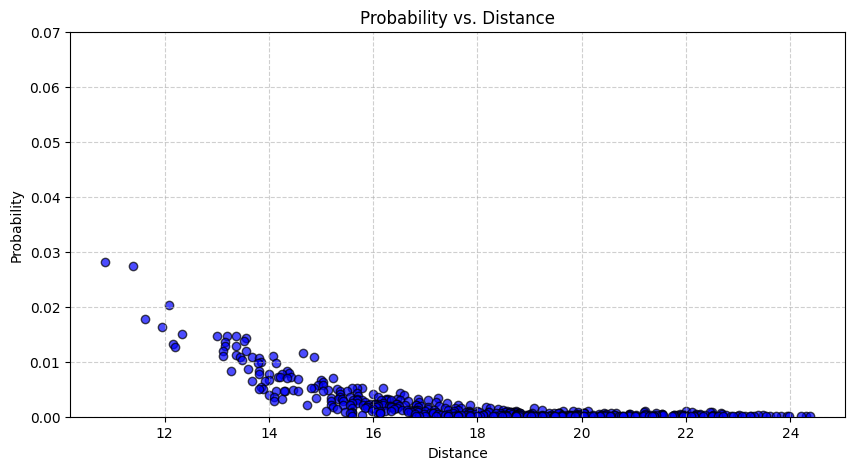

In [18]:
plt.figure(figsize=(10, 5))

# Creating the scatter plot
plt.scatter(distances9, probs9, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.07) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("figures/10QubitCase_8Qubits_ProbsDistances.png", dpi=150, bbox_inches="tight")
plt.show()

## **2. Implementación con 10 Qubits**

In [19]:
seed = 42

In [20]:
tenQubit = sl.schnorrCVP(N10, 4, 1, seed, verbose = False)

### **2.1 Algoritmo de Schnorr**

In [21]:
tenQubit.set_n(10)
tenQubit.set_smoothbound(200)

diag_yan = [3, 2, 3, 1, 1, 3, 1, 1, 2, 2]

print(f'La dimension del retículo que vamos a tratar es n = {tenQubit.get_n()}')
print(f'La cota smooth que vamos a tomar es Smooth Bound = {tenQubit.get_smoothbound()}')

La dimension del retículo que vamos a tratar es n = 10
La cota smooth que vamos a tomar es Smooth Bound = 200


In [22]:
cvpinstance = tenQubit.generate_cvp(10, diagonal = diag_yan)

B = 
[ 3 0 0 0 0 0 0 0 0 0  6931 ]
[ 0 2 0 0 0 0 0 0 0 0 10986 ]
[ 0 0 3 0 0 0 0 0 0 0 16094 ]
[ 0 0 0 1 0 0 0 0 0 0 19459 ]
[ 0 0 0 0 1 0 0 0 0 0 23979 ]
[ 0 0 0 0 0 3 0 0 0 0 25649 ]
[ 0 0 0 0 0 0 1 0 0 0 28332 ]
[ 0 0 0 0 0 0 0 1 0 0 29444 ]
[ 0 0 0 0 0 0 0 0 2 0 31355 ]
[ 0 0 0 0 0 0 0 0 0 2 33673 ]
t = 
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 331993)


In [23]:
cvpResult = tenQubit.babai_algorithm(cvpinstance, delta = 0.75)
print(f'D10 = \n{cvpResult.D}\n')
print(f'b_op10 = \n{cvpResult.b_op}\n')
print(f'res_vector10 = \n{cvpResult.res_vector}\n')
print(f'step_sign10 = \n{cvpResult.step_sign}\n')
print(f'weights10 = \n{cvpResult.weight}\n')

D10 = 
[  0  0 -3  1  2  0 -3  0  0  2  0 ]
[  0  0  0  2  0  0  3 -2 -2 -2 -2 ]
[  3  2  0  1  2 -3 -1  0 -2  0 -2 ]
[  0  0  0  4 -2 -3  0  1  0 -2  0 ]
[  0  4  0 -4  0  0  1  2 -2  0  1 ]
[  0 -4  0 -2  0  0  2 -1  0  2  3 ]
[  3  0 -3 -2  1  0  1  1  0 -2  1 ]
[  0  4  0  0 -1  0  2 -3  0  2 -2 ]
[ -3 -2  0 -1  0 -3 -2  3  2  0 -2 ]
[ -3  4  0  0  4 -3 -1 -3  2  0 -1 ]

b_op10 = 
[     3      4      0      1      2      3      2      3      2      2
 331993]

res_vector10 = 
[-3 -4  0 -1 -2 -3 -2 -3 -2 -2  0]

step_sign10 = 
[-1  1 -1  1 -1  1 -1 -1  1  1]

weights10 = 
(5953, -29824, -18221, 42395, 23869, 29891, -5953, -29225, -45689, 21514)



### **2.2 Algoritmo QAOA**

In [24]:
qubo10 = q.define_qubo(cvpResult.D, cvpResult.res_vector, cvpResult.step_sign, tenQubit.n)
print(qubo10.prettyprint())


Hc10, offset10 = q.define_hamiltonian(qubo10)
print(f'Offset = {offset10}')
print(f'Hamiltonian = \n{Hc10}')

Problem name: quboProblem

Minimize
  27*z_0^2 + 22*z_0*z_1 + 16*z_0*z_2 + 8*z_0*z_3 - 14*z_0*z_4 + 8*z_0*z_5
  + 4*z_0*z_6 - 8*z_0*z_7 - 10*z_0*z_8 - 22*z_0*z_9 + 29*z_1^2 - 14*z_1*z_2
  + 20*z_1*z_3 + 14*z_1*z_4 - 12*z_1*z_5 + 2*z_1*z_6 - 24*z_1*z_7 - 28*z_1*z_8
  + 2*z_1*z_9 + 36*z_2^2 - 18*z_2*z_3 + 10*z_2*z_4 + 36*z_2*z_5 + 12*z_2*z_6
  + 16*z_2*z_7 + 6*z_2*z_8 - 30*z_2*z_9 + 34*z_3^2 + 28*z_3*z_4 - 26*z_3*z_5
  + 10*z_3*z_6 + 10*z_3*z_7 + 16*z_3*z_8 - 4*z_3*z_9 + 42*z_4^2 + 10*z_4*z_5
  + 24*z_4*z_6 + 20*z_4*z_7 + 12*z_4*z_8 - 8*z_4*z_9 + 38*z_5^2 - 8*z_5*z_6
  + 22*z_5*z_7 - 6*z_5*z_8 - 36*z_5*z_9 + 30*z_6^2 - 16*z_6*z_7 + 16*z_6*z_8
  + 20*z_6*z_9 + 38*z_7^2 + 34*z_7*z_8 - 42*z_7*z_9 + 44*z_8^2 + 18*z_8*z_9
  + 65*z_9^2 - 6*z_0 - 12*z_1 - 14*z_2 - 20*z_3 - 32*z_4 - 26*z_5 - 20*z_6
  - 26*z_7 - 36*z_8 - 2*z_9 + 60

Subject to
  No constraints

  Binary variables (10)
    z_0 z_1 z_2 z_3 z_4 z_5 z_6 z_7 z_8 z_9

Offset = 177.0
Hamiltonian = 
SparsePauliOp(['IIIIIIIZII', 'IIIZIIII

In [25]:
circuit10 = q.construct_circuit(Hc10, reps= 1)
print(circuit10)

     ┌───┐┌────────────────┐                                        »
q_0: ┤ H ├┤ Rz((-23)*γ[0]) ├─■─────────────■────────────■───────────»
     ├───┤├───────────────┬┘ │ZZ(11*γ[0])  │            │           »
q_1: ┤ H ├┤ Rz((-8)*γ[0]) ├──■─────────────┼────────────┼───────────»
     ├───┤├───────────────┴┐               │ZZ(8*γ[0])  │           »
q_2: ┤ H ├┤ Rz((-39)*γ[0]) ├───────────────■────────────┼───────────»
     ├───┤├────────────────┤                            │ZZ(4*γ[0]) »
q_3: ┤ H ├┤ Rz((-36)*γ[0]) ├────────────────────────────■───────────»
     ├───┤├────────────────┤                                        »
q_4: ┤ H ├┤ Rz((-58)*γ[0]) ├────────────────────────────────────────»
     ├───┤├───────────────┬┘                                        »
q_5: ┤ H ├┤ Rz((-6)*γ[0]) ├─────────────────────────────────────────»
     ├───┤├───────────────┴┐                                        »
q_6: ┤ H ├┤ Rz((-42)*γ[0]) ├────────────────────────────────────────»
     ├───┤├─────────

In [26]:
x0 = np.asarray([0.0]*circuit10.num_parameters)
monitor, optParameters10 = q.qaoa_algorithm(circuit10, Hc10, x0)

In [27]:
print(f'Iteraciones = {monitor.iterations}')
print(f'Evolucion: ')
for angles, value in zip(monitor.parameters, monitor.evaluation):
    print(f'{angles}: {value}')

Iteraciones = 51
Evolucion: 
[-0.0005    0.000375]: -0.003483558641774821
[-0.00075    0.0009375]: -0.013056034474713223
[-0.001875    0.00146875]: -0.05108518625907177
[-0.0029375   0.00285937]: -0.15509494935453105
[-0.00571875  0.00461719]: -0.4826190152559398
[-0.00923438  0.00827734]: -1.347287287690014
[-0.01655469  0.01362305]: -3.6288633437585616
[-0.02724609  0.02361621]: -7.713791714019326
[-0.04723242  0.0393042 ]: -9.563533881469361
[-0.04723242  0.0393042 ]: -9.563533881469361
[-0.03732654  0.03172885]: -9.800256968712699
[-0.03697742  0.03065427]: -9.920882961681345
[-0.0421922   0.03524788]: -10.044179064437573
[-0.04410135  0.03539552]: -10.43791200064051
[-0.04410135  0.03539552]: -10.43791200064051
[-0.04186077  0.03207949]: -10.880948620053472
[-0.04881898  0.03523654]: -11.5874895056719
[-0.04781693  0.03018301]: -12.8642889920399
[-0.06123233  0.03397036]: -15.007922971748101
[-0.06593592  0.02575697]: -18.340545063504
[-0.09511853  0.02922496]: -25.240171369643253

In [28]:
for param in optParameters10.items():
    print(f'{param[0]} = {param[1]}')

β[0] = -0.4906189556221089
γ[0] = 0.024643835357168208


In [29]:
results10 = q.sample_from_parameters(circuit10, list(optParameters10.values()), shots = 10_000)
print(len(results10))
for bitstring, count in results10.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

606
Bistring: 0000000000 -> Counts: 250
Bistring: 0100100010 -> Counts: 215
Bistring: 0100000010 -> Counts: 197
Bistring: 0000101000 -> Counts: 195
Bistring: 1010100010 -> Counts: 172
Bistring: 0010000010 -> Counts: 164
Bistring: 0000100000 -> Counts: 160
Bistring: 1010000110 -> Counts: 139
Bistring: 0100000110 -> Counts: 133
Bistring: 0000000010 -> Counts: 132
Bistring: 0000000001 -> Counts: 130
Bistring: 1010000001 -> Counts: 126
Bistring: 0000010000 -> Counts: 125
Bistring: 0011000010 -> Counts: 116
Bistring: 1000101000 -> Counts: 108
Bistring: 0000001100 -> Counts: 107
Bistring: 0000010001 -> Counts: 107
Bistring: 1010000010 -> Counts: 102
Bistring: 1010100001 -> Counts: 102
Bistring: 0000001000 -> Counts: 101
Bistring: 0000100010 -> Counts: 100
Bistring: 0010000000 -> Counts: 100
Bistring: 0000000100 -> Counts: 97
Bistring: 0100000000 -> Counts: 95
Bistring: 0001100000 -> Counts: 94
Bistring: 0100100000 -> Counts: 90
Bistring: 0001000000 -> Counts: 87
Bistring: 0100000001 -> Count

### **2.3 Obtención de SR-Pairs**

In [30]:
nD10 = sl.integer_to_matrix(cvpResult.D)
vnew10 = sl.bitstring2latticeVectors(nD10, results10.keys(), cvpResult.step_sign, cvpResult.b_op)
for vect10 in vnew10:
    print(vect10)

[     3      4      0      1      2      3      2      3      2      2
 331993]
[     0     -2      0      0      2      0      5      3      2      2
 331992]
[     0      2      0      2      2      0      3      4      2      0
 331989]
[     3      0      0      3      0      0      4      3      2      2
 331996]
[     0      0      0      1      7      0      4      0      2      0
 331995]
[     3      0      0      3      3      3      3      4      0     -2
 331993]
[     3      0      0     -1      2      3      4      2      2      4
 331996]
[    -3      2      0      2      5      3      3      1      4     -2
 331994]
[    -3      0      0      1      0      3      4      4      4      0
 331991]
[     3      4      0      3      2      3      5      1      0      0
 331991]
[     3      4      3      0      0      3      5      3      2      0
 331993]
[     0      4      3      0      5      0      2      3      4     -2
 331994]
[     3      0      0      5      2     

In [31]:
distances10 = utils.get_distances(vnew10, cvpinstance.t)

In [32]:
nB10 = sl.integer_to_matrix(cvpinstance.B)
uv_pairs10 = sl.vectors2uv_pairs(nB10, vnew10, tenQubit.n)
for pair10 in uv_pairs10:
    print(pair10)

[262049748526566 1]
[785989264048241 3]
[261933899831373 1]
[262123789565918 1]
[262041669463651 1]
[7599879238585634 29]
[1834786083877318 7]
[15197779877823543 58]
[523970882661499 2]
[261995333265666 1]
[262071085476330 1]
[7599591655592805 29]
[262002304109546 1]
[262027921960805 1]
[3406495379313411 13]
[31715649309334263 121]
[262023637196230 1]
[7597394977286961 29]
[12843754318516495 49]
[262061237653362 1]
[262057869447374 1]
[262119231019646 1]
[262101312821829 1]
[261988302332823 1]
[262075411643045 1]
[38521473014936659 147]
[262012871275155 1]
[1834067439956055 7]
[4455399847833935 17]
[7602076635180170 29]
[7599827166912145 29]
[262046886853479 1]
[243966644293976505 931]
[3407398611592591 13]
[3406772747336805 13]
[1797061490975892295 6859]
[524179336210761 2]
[34849540192451193 133]
[7596701593102335 29]
[4454570333762703 17]
[7598215740531955 29]
[262103683594025 1]
[269672266917047315 1029]
[1834672660438607 7]
[524170220305017 2]
[2882955920844965 11]
[98822605541643

In [33]:
sr_pairs10 = sl.uv_pairs2sr_pairs(uv_pairs10, tenQubit)
print(sr_pairs10)

[((785989264048241, 3), 46266369554)]


In [34]:
probs10 = utils.get_probs(results10.values(), shots = 10_000)

In [35]:
utils.prettyprint(vnew10, distances10, probs10, cvpResult.b_op, cvpResult.res_vector)

Vector más corto por algoritmo de Babai: 
b_op = [     3      4      0      1      2      3      2      3      2      2
 331993]

El vector residual 
t - b_op = [-3 -4  0 -1 -2 -3 -2 -3 -2 -2  0]

La distancia |t - b_op| = 7.746

0: Prob = 0.02500
	vnew = [     3      4      0      1      2      3      2      3      2      2
 331993] con distancia: 7.746
1: Prob = 0.02150
	vnew = [     0     -2      0      0      2      0      5      3      2      2
 331992] con distancia: 7.141
2: Prob = 0.01970
	vnew = [     0      2      0      2      2      0      3      4      2      0
 331989] con distancia: 7.550
3: Prob = 0.01950
	vnew = [     3      0      0      3      0      0      4      3      2      2
 331996] con distancia: 7.746
4: Prob = 0.01720
	vnew = [     0      0      0      1      7      0      4      0      2      0
 331995] con distancia: 8.602
5: Prob = 0.01640
	vnew = [     3      0      0      3      3      3      3      4      0     -2
 331993] con distancia: 8.062
6: Prob 

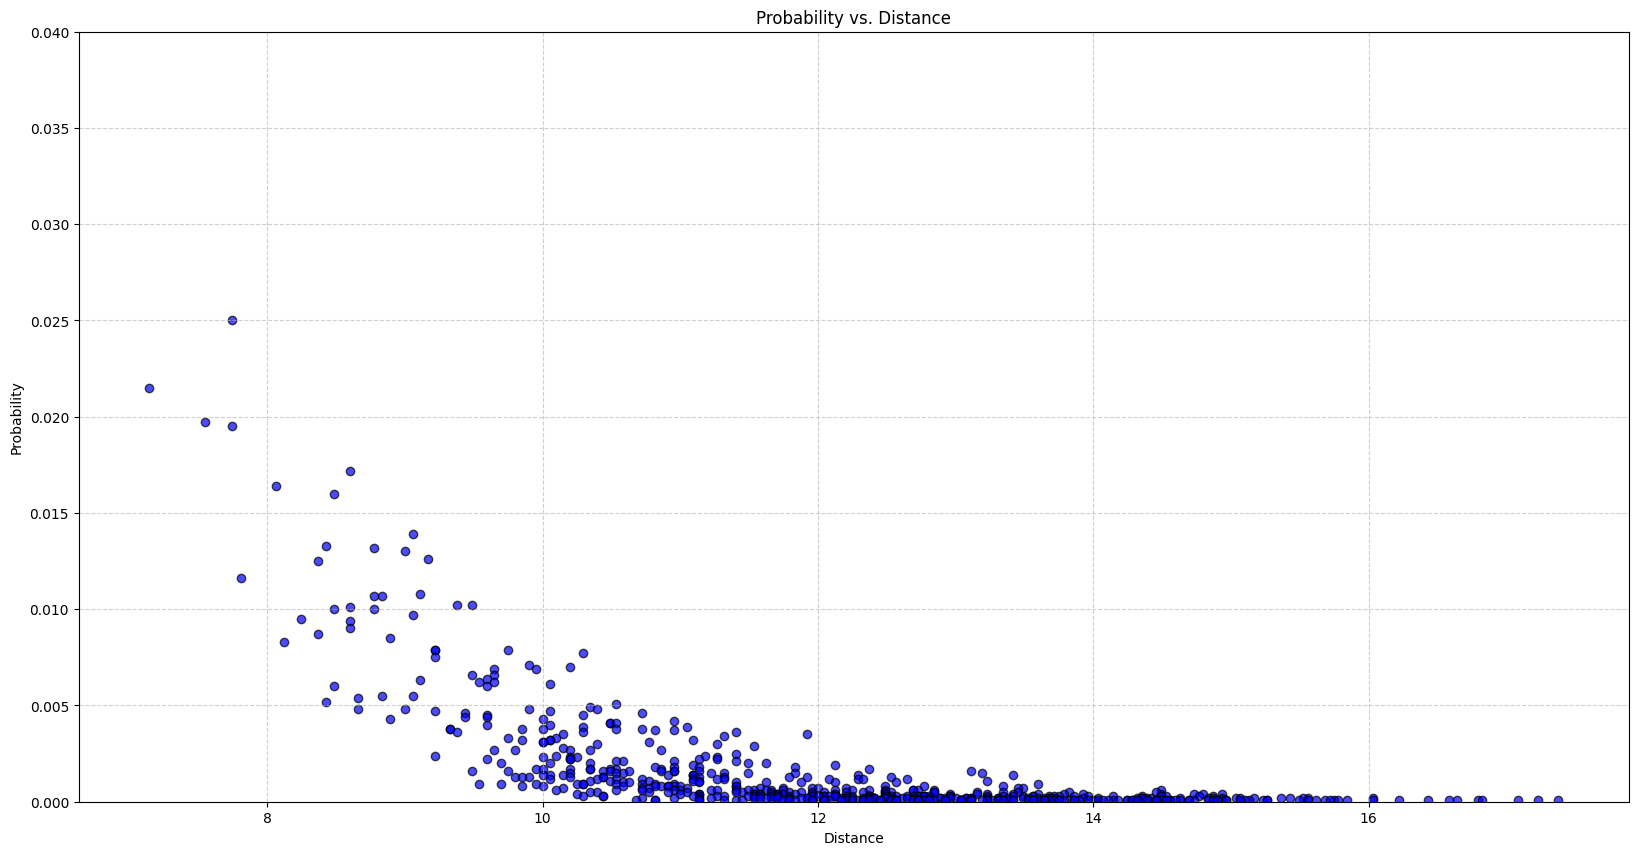

In [36]:
plt.figure(figsize=(20, 10))

# Creating the scatter plot
plt.scatter(distances10, probs10, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.04) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("figures/10QubitCase_10Qubits_ProbsDistances.png", dpi=150, bbox_inches="tight")
plt.show()